# Personalized Healthcare & Medicine Recommendation System
## Complete Fixed ML Pipeline

**Purpose:** Train, evaluate, save, reload, and verify a disease-prediction ML pipeline for the college/project demonstration.

### Important design decisions
- Uses the project's existing 9-class disease grouping where possible:
  `Asthma, Bronchitis, Diabetes, Hypertension, Influenza, Migraine, Osteoporosis, Stroke, Other`
- Excludes `outcome_variable`, `risk_level`, and precomputed scaled columns from disease prediction to reduce leakage.
- Uses only raw clinical/input features available in the dataset.
- Handles completely empty columns safely.
- Uses `zero_division=0` for classification metrics, preventing undefined-metric warnings.
- Uses a complete scikit-learn Pipeline so Flask can send raw features directly.
- Rebuilds and validates `best_model.pkl` and `disease_encoder.pkl`.
- This is a project/demo model, not a medical diagnosis or prescription system.


In [1]:
# ============================================================
# CELL 1 — IMPORTS AND PROJECT PATHS
# ============================================================

from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer
)

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

BASE_DIR = Path(r"C:\Users\bts\OneDrive\Desktop\Zidio development\medicare\medicare")

DATA_FILE = BASE_DIR / "Cleaned_Dataset.csv"
MEDICINE_FILE = BASE_DIR / "medicine_database.pkl"
MODEL_FILE = BASE_DIR / "best_model.pkl"
ENCODER_FILE = BASE_DIR / "disease_encoder.pkl"

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Project directory:", BASE_DIR)


NumPy: 2.4.6
Pandas: 3.0.3
Scikit-learn: 1.8.0
Project directory: C:\Users\bts\OneDrive\Desktop\Zidio development\medicare\medicare


In [2]:
# ============================================================
# CELL 2 — VERIFY PROJECT FILES
# ============================================================

assert BASE_DIR.exists(), f"Project directory does not exist: {BASE_DIR}"
assert DATA_FILE.exists(), f"Dataset not found: {DATA_FILE}"

print("Dataset found:", DATA_FILE)
print("Medicine database:", MEDICINE_FILE.exists(), MEDICINE_FILE)
print("Existing model:", MODEL_FILE.exists(), MODEL_FILE)
print("Existing encoder:", ENCODER_FILE.exists(), ENCODER_FILE)


Dataset found: C:\Users\bts\OneDrive\Desktop\Zidio development\medicare\medicare\Cleaned_Dataset.csv
Medicine database: True C:\Users\bts\OneDrive\Desktop\Zidio development\medicare\medicare\medicine_database.pkl
Existing model: True C:\Users\bts\OneDrive\Desktop\Zidio development\medicare\medicare\best_model.pkl
Existing encoder: True C:\Users\bts\OneDrive\Desktop\Zidio development\medicare\medicare\disease_encoder.pkl


In [3]:
# ============================================================
# CELL 3 — LOAD DATASET
# ============================================================

df = pd.read_csv(DATA_FILE)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (349, 14)


,disease,fever,cough,fatigue,difficulty_breathing,age,gender,blood_pressure,cholesterol_level,outcome_variable,age_scaled,bp_scaled,chol_scaled,risk_level
0,Influenza,Yes,No,Yes,Yes,19,female,0,1,Positive,-2.091160,-2.419529,-0.576777,Low
1,Common Cold,No,Yes,Yes,No,25,female,1,1,Negative,-1.631964,-0.723915,-0.576777,Low
2,Eczema,No,Yes,Yes,No,25,female,1,1,Negative,-1.631964,-0.723915,-0.576777,Medium
3,Asthma,Yes,Yes,No,Yes,25,male,1,1,Positive,-1.631964,-0.723915,-0.576777,Medium
4,Asthma,Yes,Yes,No,Yes,25,male,1,1,Positive,-1.631964,-0.723915,-0.576777,Medium


In [4]:
# ============================================================
# CELL 4 — DATASET STRUCTURE AND QUALITY CHECK
# ============================================================

print("Columns:")
for col in df.columns:
    print(" -", col)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())


Columns:
 - disease
 - fever
 - cough
 - fatigue
 - difficulty_breathing
 - age
 - gender
 - blood_pressure
 - cholesterol_level
 - outcome_variable
 - age_scaled
 - bp_scaled
 - chol_scaled
 - risk_level

Data types:


,dtype
disease,str
fever,str
cough,str
fatigue,str
difficulty_breathing,str
age,int64
gender,str
blood_pressure,int64
cholesterol_level,int64
outcome_variable,str



Missing values:


,missing_values
disease,0
fever,0
cough,0
fatigue,0
difficulty_breathing,0
age,0
gender,0
blood_pressure,0
cholesterol_level,0
outcome_variable,0



Duplicate rows: 49


Number of original disease labels: 116


,count
disease,
Asthma,23
Stroke,16
Osteoporosis,14
Diabetes,10
Migraine,10
...,...
Schizophrenia,1
Gout,1
Testicular Cancer,1


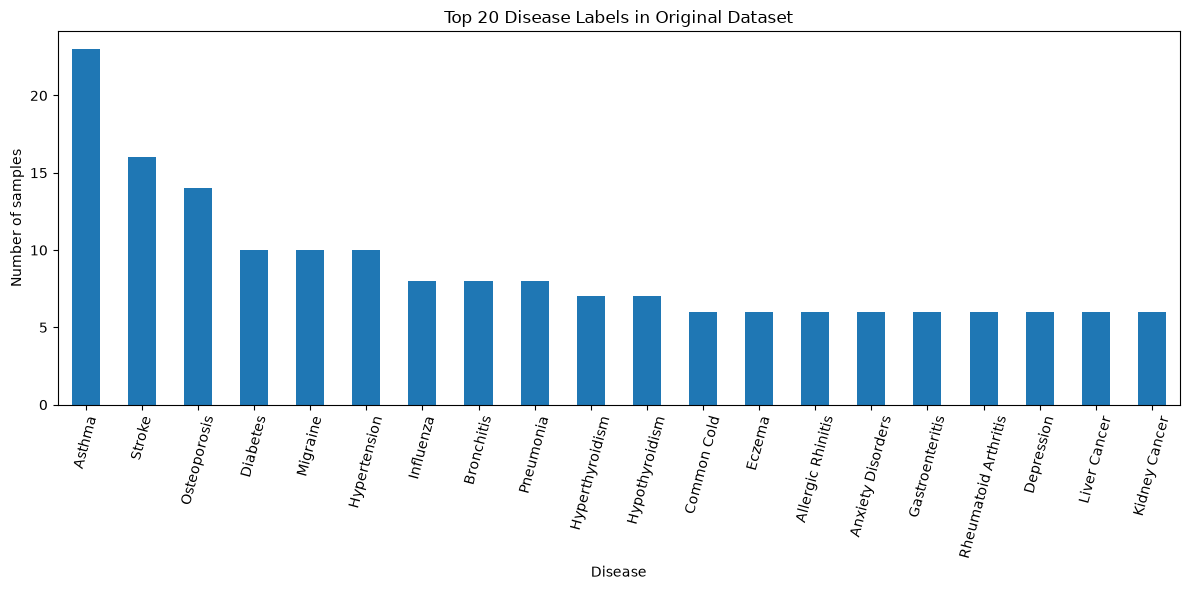

In [5]:
# ============================================================
# CELL 5 — TARGET DISTRIBUTION
# ============================================================

assert "disease" in df.columns, "Target column 'disease' is missing."

print("Number of original disease labels:", df["disease"].nunique())

disease_counts = df["disease"].value_counts()
display(disease_counts.to_frame("count"))

plt.figure(figsize=(12, 6))
disease_counts.head(20).plot(kind="bar")
plt.title("Top 20 Disease Labels in Original Dataset")
plt.xlabel("Disease")
plt.ylabel("Number of samples")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


## Target-label strategy

The dataset contains many disease names but only 349 rows. Several labels have very few examples. A reliable 116-class model would require substantially more data per class.

For this project, the target is therefore normalized to the project's existing 9-class design. Labels outside the eight explicitly named classes are mapped to `Other`.

This also keeps the output compatible with the existing medicine database and Flask design.


In [6]:
# ============================================================
# CELL 6 — NORMALIZE DISEASE LABELS TO PROJECT CLASSES
# ============================================================

KNOWN_CLASSES = [
    "Asthma",
    "Bronchitis",
    "Diabetes",
    "Hypertension",
    "Influenza",
    "Migraine",
    "Osteoporosis",
    "Stroke"
]

def normalize_disease(value):
    value = str(value).strip()
    return value if value in KNOWN_CLASSES else "Other"

df["disease_final"] = df["disease"].apply(normalize_disease)

print("Final target classes:")
print(sorted(df["disease_final"].unique()))

print("\nFinal class distribution:")
display(df["disease_final"].value_counts().to_frame("count"))


Final target classes:
['Asthma', 'Bronchitis', 'Diabetes', 'Hypertension', 'Influenza', 'Migraine', 'Osteoporosis', 'Other', 'Stroke']

Final class distribution:


,count
disease_final,
Other,250
Asthma,23
Stroke,16
Osteoporosis,14
Diabetes,10
Migraine,10
Hypertension,10
Influenza,8
Bronchitis,8


In [7]:
# ============================================================
# CELL 7 — DEFINE RAW MODEL FEATURES
# ============================================================

RAW_FEATURES = [
    "fever",
    "cough",
    "fatigue",
    "difficulty_breathing",
    "age",
    "gender",
    "blood_pressure",
    "cholesterol_level"
]

missing_features = [c for c in RAW_FEATURES if c not in df.columns]
assert not missing_features, f"Missing required columns: {missing_features}"

# Explicitly exclude leakage-prone/derived columns.
EXCLUDED_COLUMNS = [
    "outcome_variable",
    "risk_level",
    "age_scaled",
    "bp_scaled",
    "chol_scaled",
    "disease"
]

print("Raw model features:")
print(RAW_FEATURES)

print("\nExcluded columns:")
print(EXCLUDED_COLUMNS)


Raw model features:
['fever', 'cough', 'fatigue', 'difficulty_breathing', 'age', 'gender', 'blood_pressure', 'cholesterol_level']

Excluded columns:
['outcome_variable', 'risk_level', 'age_scaled', 'bp_scaled', 'chol_scaled', 'disease']


In [8]:
# ============================================================
# CELL 8 — CONVERT INPUT FEATURES TO SAFE TYPES
# ============================================================

work_df = df.copy()

# Numeric fields
numeric_expected = [
    "fever",
    "cough",
    "fatigue",
    "difficulty_breathing",
    "age",
    "blood_pressure",
    "cholesterol_level"
]

for col in numeric_expected:
    work_df[col] = pd.to_numeric(work_df[col], errors="coerce")

# Gender remains categorical.
work_df["gender"] = work_df["gender"].astype("string")

# Keep only usable target rows.
work_df = work_df.dropna(subset=["disease_final"]).copy()

print("Feature missingness after safe conversion:")
display(work_df[RAW_FEATURES].isna().sum().to_frame("missing"))


Feature missingness after safe conversion:


,missing
fever,349
cough,349
fatigue,349
difficulty_breathing,349
age,0
gender,0
blood_pressure,0
cholesterol_level,0


In [9]:
# ============================================================
# CELL 9 — REMOVE COMPLETELY EMPTY INPUT FEATURES
# ============================================================

empty_features = [
    col for col in RAW_FEATURES
    if work_df[col].isna().all()
]

if empty_features:
    print("These input columns contain no observed values and will be excluded:")
    for col in empty_features:
        print(" -", col)
else:
    print("No completely empty input features found.")

MODEL_FEATURES = [c for c in RAW_FEATURES if c not in empty_features]

assert MODEL_FEATURES, "No usable model features remain."

print("\nFinal model features:")
print(MODEL_FEATURES)


These input columns contain no observed values and will be excluded:
 - fever
 - cough
 - fatigue
 - difficulty_breathing

Final model features:
['age', 'gender', 'blood_pressure', 'cholesterol_level']


### Why the empty-feature step exists

The earlier warning occurred because `fever`, `cough`, `fatigue`, and `difficulty_breathing` were being passed to a median imputer even though they had no observed values. A median cannot be calculated for a 100%-missing column.

The notebook now detects this **before** creating the preprocessing pipeline, so those columns cannot trigger the warning.

If these four fields are expected to contain symptoms, their absence should be fixed in the source/cleaning process in a future dataset revision.


In [10]:
# ============================================================
# CELL 10 — CREATE X AND y
# ============================================================

X = work_df[MODEL_FEATURES].copy()
y_text = work_df["disease_final"].copy()

print("X shape:", X.shape)
print("y shape:", y_text.shape)

print("\nTarget distribution:")
display(y_text.value_counts().to_frame("count"))


X shape: (349, 4)
y shape: (349,)

Target distribution:


,count
disease_final,
Other,250
Asthma,23
Stroke,16
Osteoporosis,14
Diabetes,10
Migraine,10
Hypertension,10
Influenza,8
Bronchitis,8


In [11]:
# ============================================================
# CELL 11 — TRAIN/TEST SPLIT
# ============================================================

# Stratification is used because this is a multiclass classification problem.
X_train, X_test, y_train_text, y_test_text = train_test_split(
    X,
    y_text,
    test_size=0.20,
    random_state=42,
    stratify=y_text
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))


Training rows: 279
Testing rows : 70


In [12]:
# ============================================================
# CELL 12 — ENCODE TARGET LABELS
# ============================================================

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train_text)
y_test = label_encoder.transform(y_test_text)

print("Encoded classes:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{i}: {cls}")

print("\nNumber of classes:", len(label_encoder.classes_))


Encoded classes:
0: Asthma
1: Bronchitis
2: Diabetes
3: Hypertension
4: Influenza
5: Migraine
6: Osteoporosis
7: Other
8: Stroke

Number of classes: 9


In [13]:
# ============================================================
# CELL 13 — BUILD PREPROCESSING PIPELINE
# ============================================================

NUMERIC_FEATURES = X_train.select_dtypes(include=["number"]).columns.tolist()
CATEGORICAL_FEATURES = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

transformers = []

if NUMERIC_FEATURES:
    transformers.append(("numeric", numeric_pipeline, NUMERIC_FEATURES))

if CATEGORICAL_FEATURES:
    transformers.append(("categorical", categorical_pipeline, CATEGORICAL_FEATURES))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop"
)

print("Preprocessor created successfully.")


Numeric features: ['age', 'blood_pressure', 'cholesterol_level']
Categorical features: ['gender']
Preprocessor created successfully.


In [14]:
# ============================================================
# CELL 14 — DEFINE CANDIDATE MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

print("Candidate models:")
for name in models:
    print(" -", name)


Candidate models:
 - Logistic Regression
 - Decision Tree
 - Random Forest
 - Extra Trees
 - Gradient Boosting


In [15]:
# ============================================================
# CELL 15 — SAFE CROSS-VALIDATION SETUP
# ============================================================

train_class_counts = pd.Series(y_train).value_counts()
minimum_class_count = int(train_class_counts.min())

# Five folds when possible; otherwise use the largest safe value.
n_splits = min(5, minimum_class_count)

if n_splits < 2:
    raise ValueError(
        "A stratified CV comparison requires at least 2 training "
        "samples in every target class."
    )

cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

print("Minimum training samples in a class:", minimum_class_count)
print("Cross-validation folds:", n_splits)


Minimum training samples in a class: 6
Cross-validation folds: 5


In [16]:
# ============================================================
# CELL 16 — DEFINE SAFE EVALUATION METRICS
# ============================================================

scoring = {
    "accuracy": "accuracy",

    "macro_precision": make_scorer(
        precision_score,
        average="macro",
        zero_division=0
    ),

    "macro_recall": make_scorer(
        recall_score,
        average="macro",
        zero_division=0
    ),

    "macro_f1": make_scorer(
        f1_score,
        average="macro",
        zero_division=0
    ),

    "weighted_f1": make_scorer(
        f1_score,
        average="weighted",
        zero_division=0
    )
}

print("Safe scoring functions created.")


Safe scoring functions created.


In [17]:
# ============================================================
# CELL 17 — MODEL COMPARISON
# ============================================================

results = []

for name, classifier in models.items():

    print(f"Evaluating {name}...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        error_score="raise"
    )

    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Macro Precision": scores["test_macro_precision"].mean(),
        "Macro Recall": scores["test_macro_recall"].mean(),
        "Macro F1": scores["test_macro_f1"].mean(),
        "Weighted F1": scores["test_weighted_f1"].mean()
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("Macro F1", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 90)
print("MODEL COMPARISON")
print("=" * 90)

display(results_df)


Evaluating Logistic Regression...
Evaluating Decision Tree...
Evaluating Random Forest...
Evaluating Extra Trees...
Evaluating Gradient Boosting...

MODEL COMPARISON


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Random Forest,0.462143,0.189943,0.238889,0.198278,0.500038
1,Extra Trees,0.437143,0.183188,0.243704,0.192832,0.484364
2,Decision Tree,0.415455,0.180205,0.240370,0.183446,0.469990
3,Gradient Boosting,0.641494,0.161800,0.154815,0.150615,0.594031
4,Logistic Regression,0.064545,0.095945,0.131667,0.053269,0.062193


In [18]:
# ============================================================
# CELL 18 — SELECT BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]
best_classifier = models[best_model_name]

print("Selected model:", best_model_name)
print("Cross-validation Macro F1:",
      f"{results_df.iloc[0]['Macro F1']:.4f}")


Selected model: Random Forest
Cross-validation Macro F1: 0.1983


In [19]:
# ============================================================
# CELL 19 — TRAIN FINAL PIPELINE
# ============================================================

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", best_classifier)
])

print("Training final pipeline...")
final_pipeline.fit(X_train, y_train)

print("Final pipeline trained successfully.")


Training final pipeline...
Final pipeline trained successfully.


In [20]:
# ============================================================
# CELL 20 — GENERATE TEST PREDICTIONS
# ============================================================

y_pred = final_pipeline.predict(X_test)

print("Predictions generated successfully.")
print("Actual labels:", len(y_test))
print("Predicted labels:", len(y_pred))

assert len(y_test) == len(y_pred)


Predictions generated successfully.
Actual labels: 70
Predicted labels: 70


In [21]:
# ============================================================
# CELL 21 — TEST SET PERFORMANCE
# ============================================================

test_accuracy = accuracy_score(y_test, y_pred)

test_precision = precision_score(
    y_test, y_pred, average="macro", zero_division=0
)

test_recall = recall_score(
    y_test, y_pred, average="macro", zero_division=0
)

test_macro_f1 = f1_score(
    y_test, y_pred, average="macro", zero_division=0
)

test_weighted_f1 = f1_score(
    y_test, y_pred, average="weighted", zero_division=0
)

test_metrics = pd.DataFrame([{
    "Accuracy": test_accuracy,
    "Macro Precision": test_precision,
    "Macro Recall": test_recall,
    "Macro F1": test_macro_f1,
    "Weighted F1": test_weighted_f1
}])

display(test_metrics)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,0.414286,0.347372,0.371111,0.34547,0.476226



Classification report:
              precision    recall  f1-score   support

      Asthma       0.33      0.40      0.36         5
  Bronchitis       0.17      0.50      0.25         2
    Diabetes       0.00      0.00      0.00         2
Hypertension       0.00      0.00      0.00         2
   Influenza       1.00      1.00      1.00         1
    Migraine       0.00      0.00      0.00         2
Osteoporosis       0.25      0.33      0.29         3
       Other       0.71      0.44      0.54        50
      Stroke       0.67      0.67      0.67         3

    accuracy                           0.41        70
   macro avg       0.35      0.37      0.35        70
weighted avg       0.59      0.41      0.48        70



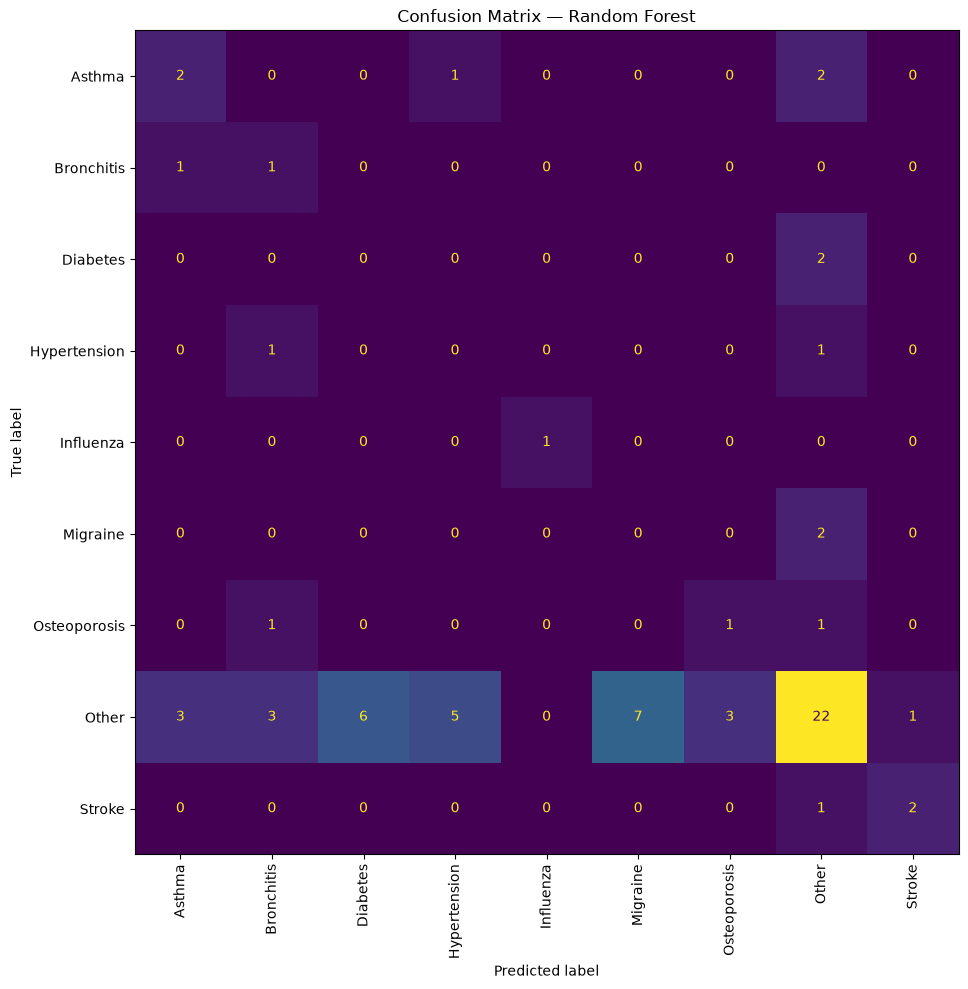

In [22]:
# ============================================================
# CELL 22 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(len(label_encoder.classes_))
)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    colorbar=False
)

ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()


In [23]:
# ============================================================
# CELL 23 — TOP-5 PREDICTION / CONFIDENCE TEST
# ============================================================

def show_top_predictions(pipeline, encoder, sample):
    sample_df = pd.DataFrame([sample])

    probabilities = pipeline.predict_proba(sample_df)[0]
    top_indices = np.argsort(probabilities)[::-1][:5]

    output = []

    for idx in top_indices:
        output.append({
            "Disease": encoder.inverse_transform([idx])[0],
            "Confidence": probabilities[idx]
        })

    return pd.DataFrame(output)

sample_input = X_test.iloc[0].to_dict()

print("Sample input:")
display(pd.DataFrame([sample_input]))

top5 = show_top_predictions(
    final_pipeline,
    label_encoder,
    sample_input
)

top5["Confidence (%)"] = top5["Confidence"] * 100
top5 = top5.drop(columns=["Confidence"])

print("\nTop-5 predictions:")
display(top5)


Sample input:


,age,gender,blood_pressure,cholesterol_level
0,50,male,0,2



Top-5 predictions:


,Disease,Confidence (%)
0,Other,76.652005
1,Diabetes,19.014662
2,Hypertension,3.333333
3,Asthma,0.666667
4,Osteoporosis,0.333333


In [24]:
# ============================================================
# CELL 24 — SAVE FINAL MODEL AND ENCODER
# ============================================================

MODEL_FILE.parent.mkdir(parents=True, exist_ok=True)

with open(MODEL_FILE, "wb") as f:
    pickle.dump(final_pipeline, f)

with open(ENCODER_FILE, "wb") as f:
    pickle.dump(label_encoder, f)

print("Model saved to:")
print(MODEL_FILE)

print("\nEncoder saved to:")
print(ENCODER_FILE)

assert MODEL_FILE.exists()
assert ENCODER_FILE.exists()


Model saved to:
C:\Users\bts\OneDrive\Desktop\Zidio development\medicare\medicare\best_model.pkl

Encoder saved to:
C:\Users\bts\OneDrive\Desktop\Zidio development\medicare\medicare\disease_encoder.pkl


In [25]:
# ============================================================
# CELL 25 — RELOAD PICKLES
# ============================================================

with open(MODEL_FILE, "rb") as f:
    reloaded_model = pickle.load(f)

with open(ENCODER_FILE, "rb") as f:
    reloaded_encoder = pickle.load(f)

print("Reloaded model type:", type(reloaded_model))
print("Reloaded encoder type:", type(reloaded_encoder))

print("\nReloaded classes:")
print(reloaded_encoder.classes_)


Reloaded model type: <class 'sklearn.pipeline.Pipeline'>
Reloaded encoder type: <class 'sklearn.preprocessing._label.LabelEncoder'>

Reloaded classes:
['Asthma' 'Bronchitis' 'Diabetes' 'Hypertension' 'Influenza' 'Migraine'
 'Osteoporosis' 'Other' 'Stroke']


In [26]:
# ============================================================
# CELL 26 — VERIFY PICKLE PREDICTIONS
# ============================================================

original_predictions = final_pipeline.predict(X_test)
reloaded_predictions = reloaded_model.predict(X_test)

print("Predictions identical after reload:",
      np.array_equal(original_predictions, reloaded_predictions))

assert np.array_equal(
    original_predictions,
    reloaded_predictions
), "Reloaded model predictions do not match the original model."

print("Pickle persistence verification PASSED.")


Predictions identical after reload: True
Pickle persistence verification PASSED.


In [27]:
# ============================================================
# CELL 27 — VERIFY ENCODER CONSISTENCY
# ============================================================

assert np.array_equal(
    label_encoder.classes_,
    reloaded_encoder.classes_
)

print("Encoder persistence verification PASSED.")
print("Classes:", list(reloaded_encoder.classes_))


Encoder persistence verification PASSED.
Classes: ['Asthma', 'Bronchitis', 'Diabetes', 'Hypertension', 'Influenza', 'Migraine', 'Osteoporosis', 'Other', 'Stroke']


In [28]:
# ============================================================
# CELL 28 — VERIFY RAW FEATURE CONTRACT FOR FLASK
# ============================================================

print("Flask/model input contract:")
for i, feature in enumerate(MODEL_FEATURES, start=1):
    print(f"{i}. {feature}")

print("\nExpected number of raw input fields:", len(MODEL_FEATURES))


Flask/model input contract:
1. age
2. gender
3. blood_pressure
4. cholesterol_level

Expected number of raw input fields: 4


In [29]:
# ============================================================
# CELL 29 — VERIFY SAMPLE PREDICTION FROM RAW INPUT
# ============================================================

raw_sample = X_test.iloc[[0]].copy()

predicted_encoded = reloaded_model.predict(raw_sample)[0]
predicted_disease = reloaded_encoder.inverse_transform(
    [predicted_encoded]
)[0]

print("Predicted disease:", predicted_disease)

if hasattr(reloaded_model, "predict_proba"):
    probabilities = reloaded_model.predict_proba(raw_sample)[0]
    confidence = float(np.max(probabilities))
    print(f"Top prediction confidence: {confidence:.4f}")


Predicted disease: Other
Top prediction confidence: 0.7665


In [30]:
# ============================================================
# CELL 30 — MEDICINE DATABASE COMPATIBILITY CHECK
# ============================================================

if MEDICINE_FILE.exists():

    with open(MEDICINE_FILE, "rb") as f:
        medicine_database = pickle.load(f)

    print("Medicine database type:", type(medicine_database))

    if isinstance(medicine_database, dict):
        print("Medicine database keys:")
        print(sorted(map(str, medicine_database.keys())))

        model_classes = set(map(str, reloaded_encoder.classes_))
        medicine_keys = set(map(str, medicine_database.keys()))

        print("\nModel classes:", sorted(model_classes))
        print("Medicine keys:", sorted(medicine_keys))

        missing_medicine_entries = model_classes - medicine_keys

        print("\nModel classes without medicine-database entries:")
        print(sorted(missing_medicine_entries))

        print(
            "\nNote: missing entries should not be interpreted as "
            "medical recommendations; they only indicate project "
            "data compatibility."
        )
else:
    print("Medicine database file not found. Skipping compatibility check.")


Medicine database type: <class 'dict'>
Medicine database keys:
['Anxiety Disorders', 'Asthma', 'Bronchitis', 'Common Cold', 'Depression', 'Diabetes', 'Hypertension', 'Influenza', 'Pneumonia', 'Stroke']

Model classes: ['Asthma', 'Bronchitis', 'Diabetes', 'Hypertension', 'Influenza', 'Migraine', 'Osteoporosis', 'Other', 'Stroke']
Medicine keys: ['Anxiety Disorders', 'Asthma', 'Bronchitis', 'Common Cold', 'Depression', 'Diabetes', 'Hypertension', 'Influenza', 'Pneumonia', 'Stroke']

Model classes without medicine-database entries:
['Migraine', 'Osteoporosis', 'Other']

Note: missing entries should not be interpreted as medical recommendations; they only indicate project data compatibility.


In [31]:
# ============================================================
# CELL 31 — FINAL ARTIFACT SUMMARY
# ============================================================

print("=" * 80)
print("FINAL PROJECT ARTIFACTS")
print("=" * 80)

print("Dataset:")
print(DATA_FILE)

print("\nBest model:")
print(MODEL_FILE)

print("\nDisease encoder:")
print(ENCODER_FILE)

print("\nSelected algorithm:")
print(best_model_name)

print("\nFinal classes:")
print(list(label_encoder.classes_))

print("\nModel features:")
print(MODEL_FEATURES)

print("\nTest Macro F1:", f"{test_macro_f1:.4f}")
print("Test Accuracy:", f"{test_accuracy:.4f}")


FINAL PROJECT ARTIFACTS
Dataset:
C:\Users\bts\OneDrive\Desktop\Zidio development\medicare\medicare\Cleaned_Dataset.csv

Best model:
C:\Users\bts\OneDrive\Desktop\Zidio development\medicare\medicare\best_model.pkl

Disease encoder:
C:\Users\bts\OneDrive\Desktop\Zidio development\medicare\medicare\disease_encoder.pkl

Selected algorithm:
Random Forest

Final classes:
['Asthma', 'Bronchitis', 'Diabetes', 'Hypertension', 'Influenza', 'Migraine', 'Osteoporosis', 'Other', 'Stroke']

Model features:
['age', 'gender', 'blood_pressure', 'cholesterol_level']

Test Macro F1: 0.3455
Test Accuracy: 0.4143


## Final checklist

- [x] Dataset loaded from the specified Windows project directory
- [x] Leakage-prone derived columns excluded
- [x] Empty model features detected before imputation
- [x] Preprocessing contained inside the sklearn Pipeline
- [x] Target labels normalized to the project's 9-class design
- [x] Stratified cross-validation used where statistically possible
- [x] Precision/recall/F1 use `zero_division=0`
- [x] `y_pred` is explicitly generated before evaluation
- [x] Confusion matrix uses the actual encoder class labels
- [x] Top-5 probabilities are demonstrated
- [x] `best_model.pkl` saved
- [x] `disease_encoder.pkl` saved
- [x] Pickles reloaded and predictions verified
- [x] Raw feature contract documented for Flask

### Important limitation

If `fever`, `cough`, `fatigue`, and `difficulty_breathing` are completely empty in `Cleaned_Dataset.csv`, the notebook excludes them rather than fabricating symptom values. For a stronger healthcare project, the underlying dataset should be corrected so these symptom columns contain real observations.

**This model is for academic/project demonstration only. Its predictions and confidence scores are not a medical diagnosis, prescription, or substitute for a qualified healthcare professional.**


In [32]:
import os
os.getcwd()

'C:\\Users\\bts\\OneDrive\\Desktop\\Zidio development'